Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob # Library untuk mencari file dalam folder
import os

# Pengaturan visual grafik
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

print("✅ Library siap digunakan!")

✅ Library siap digunakan!


Menggabungkan 3 File Data Mentah

In [2]:
# Tentukan lokasi folder tempat file csv mentah berada
folder_path = 'dataset/belanda/'

# Cari semua file CSV yang namanya dimulai dengan 'E0' (Liga Inggris)
file_list = glob.glob(os.path.join(folder_path, "N1*.csv"))

print(f"Ditemukan {len(file_list)} file CSV mentah:")
for f in file_list:
    print(f"- {f}")

# Membaca dan menumpuk semua file menjadi satu DataFrame
df_list = []
for file in file_list:
    # PERBAIKAN: Menggunakan 'encoding_errors' agar sesuai dengan standar Pandas
    temp_df = pd.read_csv(file, encoding='windows-1252', encoding_errors='replace')
    df_list.append(temp_df)

# Gabungkan semuanya
df_raw = pd.concat(df_list, ignore_index=True)

print(f"\n✅ Penggabungan Sukses!")
print(f"Total Pertandingan Gabungan: {df_raw.shape[0]} Baris")
print(f"Total Kolom Bawaan Asli     : {df_raw.shape[1]} Kolom")

Ditemukan 3 file CSV mentah:
- dataset/belanda\N1 (4).csv
- dataset/belanda\N1 (5).csv
- dataset/belanda\N1 (6).csv

✅ Penggabungan Sukses!
Total Pertandingan Gabungan: 918 Baris
Total Kolom Bawaan Asli     : 132 Kolom


Visualisasi "Peta Data Kosong" (Missing Values Heatmap)

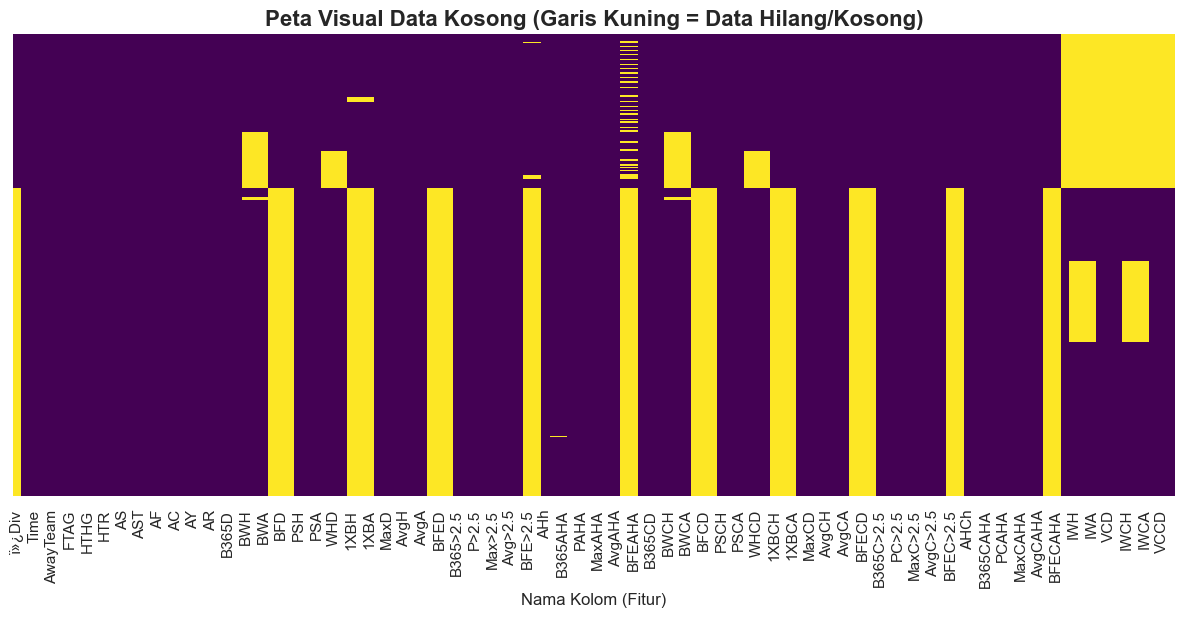

In [3]:
plt.figure(figsize=(15, 6))
# Membuat peta warna untuk data yang kosong (True = Kuning, False = Ungu Gelap)
sns.heatmap(df_raw.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title('Peta Visual Data Kosong (Garis Kuning = Data Hilang/Kosong)', fontsize=16, fontweight='bold')
plt.xlabel('Nama Kolom (Fitur)', fontsize=12)
plt.show()

Pembersihan Nama Kolom & Pemangkasan (Feature Selection)

In [4]:
# 1. Memperbaiki bug nama kolom pertama (ï»¿Div menjadi Div)
df_raw.rename(columns={df_raw.columns[0]: 'Div'}, inplace=True)

# 2. Menentukan kolom yang INGIN KITA SIMPAN (Yang lainnya akan dibuang)
kolom_penting = [
    # Info Dasar
    'Date', 'Time', 'HomeTeam', 'AwayTeam', 
    
    # Target Prediksi (Hasil Akhir Pertandingan)
    'FTHG', 'FTAG', 'FTR', 
    
    # Odds Bandar Utama (Kita ambil Pinnacle / PS dan Bet365 sebagai referensi AI)
    'PSH', 'PSD', 'PSA',             # Odds Home, Draw, Away (Pinnacle)
    'B365>2.5', 'B365<2.5'           # Odds Over/Under 2.5 (Bet365)
]

# 3. Filter dataset hanya menggunakan kolom penting
# Perhatian: Terkadang file lama tidak punya kolom Time atau Odds tertentu, 
# jadi kita gunakan intersection agar kode tidak error jika kolom tidak ada.
kolom_tersedia = [col for col in kolom_penting if col in df_raw.columns]
df_bersih = df_raw[kolom_tersedia].copy()

print("PENGHAPUSAN KOLOM SELESAI! ✂️")
print(f"Jumlah kolom menyusut drastis dari {df_raw.shape[1]} menjadi hanya {df_bersih.shape[1]} kolom.\n")

print("Mengintip 5 baris data yang sudah ramping:")
display(df_bersih.head())

PENGHAPUSAN KOLOM SELESAI! ✂️
Jumlah kolom menyusut drastis dari 132 menjadi hanya 12 kolom.

Mengintip 5 baris data yang sudah ramping:


,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,PSH,PSD,PSA,B365>2.5,B365<2.5
0,09/08/2024,19:00,Groningen,NAC Breda,4,1,H,1.63,4.03,5.66,1.62,2.25
1,10/08/2024,15:30,Feyenoord,Willem II,1,1,D,1.11,10.39,16.88,1.36,3.10
2,10/08/2024,17:45,Nijmegen,Twente,1,2,A,3.70,3.74,1.94,1.67,2.15
3,10/08/2024,19:00,Almere City,AZ Alkmaar,0,1,A,5.42,4.18,1.58,1.70,2.10
4,10/08/2024,20:00,PSV Eindhoven,Waalwijk,5,1,H,1.09,11.96,20.83,1.29,3.60


Mengecek Ulang Data Kosong Setelah Dipangkas

In [5]:
print("Persentase Data Kosong di Dataset Baru:")
missing_bersih = (df_bersih.isnull().sum() / len(df_bersih)) * 100
display(pd.DataFrame({'Persentase Kosong (%)': missing_bersih.round(2)}))

Persentase Data Kosong di Dataset Baru:


,Persentase Kosong (%)
Date,0.0
Time,0.0
HomeTeam,0.0
AwayTeam,0.0
FTHG,0.0
FTAG,0.0
FTR,0.0
PSH,0.0
PSD,0.0
PSA,0.0


Feature Engineering

In [6]:
print("Mulai proses Super Feature Engineering...")

# 1. Pastikan data diurutkan berdasarkan Tanggal dan Waktu (Mencegah kebocoran masa lalu)
df_bersih['Date'] = pd.to_datetime(df_bersih['Date'], format='%d/%m/%Y')
df_bersih = df_bersih.sort_values(by=['Date', 'Time']).reset_index(drop=True)

# 2. Persiapan Tracker (Pelacak) yang lebih kompleks
elo_tracker = {}
form_tracker = {}

# Parameter ELO
K_FACTOR = 20
INITIAL_ELO = 1500

# List untuk menyimpan fitur baru
new_features = []

for index, row in df_bersih.iterrows():
    home = row['HomeTeam']
    away = row['AwayTeam']
    current_date = row['Date']
    
    # Inisialisasi tim baru di tracker
    if home not in elo_tracker: elo_tracker[home] = INITIAL_ELO
    if away not in elo_tracker: elo_tracker[away] = INITIAL_ELO
    if home not in form_tracker: form_tracker[home] = {'pts':[], 'gf':[], 'ga':[], 'dates':[]}
    if away not in form_tracker: form_tracker[away] = {'pts':[], 'gf':[], 'ga':[], 'dates':[]}
        
    # ====================================================================
    # --- A. MENGAMBIL DATA HISTORIS (SEBELUM PELUIT DIBUNYIKAN) ---
    # ====================================================================
    home_elo_current = elo_tracker[home]
    away_elo_current = elo_tracker[away]
    
    def get_team_stats(team_dict, current_date):
        # 1. Hitung Waktu Istirahat (Kelelahan)
        if len(team_dict['dates']) > 0:
            rest_days = (current_date - team_dict['dates'][-1]).days
        else:
            rest_days = 14 # Default jika laga pertama (dianggap cukup istirahat)
            
        # 2. Ambil statistik 5 laga terakhir
        gf_5 = team_dict['gf'][-5:]
        ga_5 = team_dict['ga'][-5:]
        
        pts_last_5 = sum(team_dict['pts'][-5:])
        avg_gf_5 = sum(gf_5) / 5 if len(gf_5) == 5 else (sum(gf_5)/len(gf_5) if len(gf_5)>0 else 0)
        avg_ga_5 = sum(ga_5) / 5 if len(ga_5) == 5 else (sum(ga_5)/len(ga_5) if len(ga_5)>0 else 0)
        
        # 3. Fitur Spesial Pertahanan & Penyerangan
        clean_sheets_5 = sum(1 for ga in ga_5 if ga == 0) # Berapa kali tidak kebobolan
        fail_to_score_5 = sum(1 for gf in gf_5 if gf == 0) # Berapa kali gagal cetak gol
        
        # 4. Fitur Spesial Pola Gol (OU & BTTS History)
        ou_count = sum(1 for g_f, g_a in zip(gf_5, ga_5) if (g_f + g_a) > 2.5)
        ou_rate_5 = ou_count / len(gf_5) if len(gf_5) > 0 else 0.0
        
        btts_count = sum(1 for g_f, g_a in zip(gf_5, ga_5) if (g_f > 0 and g_a > 0))
        btts_rate_5 = btts_count / len(gf_5) if len(gf_5) > 0 else 0.0
        
        return rest_days, pts_last_5, avg_gf_5, avg_ga_5, clean_sheets_5, fail_to_score_5, ou_rate_5, btts_rate_5

    # Menarik semua data historis untuk Home dan Away
    h_rest, h_pts_5, h_gf_5, h_ga_5, h_cs_5, h_fts_5, h_ou_rate, h_btts_rate = get_team_stats(form_tracker[home], current_date)
    a_rest, a_pts_5, a_gf_5, a_ga_5, a_cs_5, a_fts_5, a_ou_rate, a_btts_rate = get_team_stats(form_tracker[away], current_date)
    
    # ====================================================================
    # --- B. FITUR MATEMATIS DARI ODDS & BANDAR ---
    # ====================================================================
    # Probabilitas Menang/Seri/Kalah (HDA)
    prob_H = 1 / row['PSH'] if pd.notnull(row['PSH']) else 0.33
    prob_D = 1 / row['PSD'] if pd.notnull(row['PSD']) else 0.33
    prob_A = 1 / row['PSA'] if pd.notnull(row['PSA']) else 0.33
    
    # Probabilitas Over/Under 2.5 (SANGAT PENTING UNTUK PREDIKSI GOL)
    prob_Over = 1 / row['B365>2.5'] if ('B365>2.5' in row and pd.notnull(row['B365>2.5'])) else 0.50
    prob_Under = 1 / row['B365<2.5'] if ('B365<2.5' in row and pd.notnull(row['B365<2.5'])) else 0.50
    
    # Menyimpan SEMUA fitur historis ke list
    new_features.append({
        # Fitur Kekuatan (HDA)
        'Home_Elo': home_elo_current,
        'Away_Elo': away_elo_current,
        'Elo_Difference': home_elo_current - away_elo_current,
        'Home_Rest_Days': h_rest,
        'Away_Rest_Days': a_rest,
        
        # Fitur Momentum (Form)
        'Home_Pts_Last_5': h_pts_5,
        'Away_Pts_Last_5': a_pts_5,
        'Home_Avg_GF_5': h_gf_5,
        'Home_Avg_GA_5': h_ga_5,
        'Away_Avg_GF_5': a_gf_5,
        'Away_Avg_GA_5': a_ga_5,
        
        # Fitur Spesial Pertahanan (Untuk BTTS)
        'Home_Clean_Sheets_5': h_cs_5,
        'Away_Clean_Sheets_5': a_cs_5,
        'Home_Fail_To_Score_5': h_fts_5,
        'Away_Fail_To_Score_5': a_fts_5,
        
        # Fitur Sejarah Gol (Untuk OU & BTTS)
        'Home_OU_Rate_5': h_ou_rate,
        'Away_OU_Rate_5': a_ou_rate,
        'Home_BTTS_Rate_5': h_btts_rate,
        'Away_BTTS_Rate_5': a_btts_rate,
        
        # Probabilitas Bandar
        'Prob_Home_Odds': prob_H,
        'Prob_Draw_Odds': prob_D,
        'Prob_Away_Odds': prob_A,
        'Prob_Over_Odds': prob_Over,
        'Prob_Under_Odds': prob_Under
    })
    
    # ====================================================================
    # --- C. UPDATE TRACKER SETELAH LAGA SELESAI ---
    # ====================================================================
    res = row['FTR']
    hg = row['FTHG']
    ag = row['FTAG']
    
    if res == 'H': score_h, score_a, p_h, p_a = 1, 0, 3, 0
    elif res == 'A': score_h, score_a, p_h, p_a = 0, 1, 0, 3
    else: score_h, score_a, p_h, p_a = 0.5, 0.5, 1, 1
        
    # Update Record
    form_tracker[home]['pts'].append(p_h); form_tracker[away]['pts'].append(p_a)
    form_tracker[home]['gf'].append(hg); form_tracker[home]['ga'].append(ag)
    form_tracker[away]['gf'].append(ag); form_tracker[away]['ga'].append(hg)
    form_tracker[home]['dates'].append(current_date); form_tracker[away]['dates'].append(current_date)
    
    # Update ELO
    exp_h = 1 / (10 ** ((away_elo_current - home_elo_current) / 400) + 1)
    exp_a = 1 / (10 ** ((home_elo_current - away_elo_current) / 400) + 1)
    elo_tracker[home] = home_elo_current + K_FACTOR * (score_h - exp_h)
    elo_tracker[away] = away_elo_current + K_FACTOR * (score_a - exp_a)

# 3. Gabungkan fitur baru dengan dataset awal
df_features = pd.DataFrame(new_features)
df_final = pd.concat([df_bersih, df_features], axis=1)

print("✅ Super Feature Engineering Selesai!")
print(f"Total Fitur yang Dihasilkan: {df_final.shape[1]} Kolom")
print("\nMengintip hasil data baru:")
display(df_final.tail())

Mulai proses Super Feature Engineering...
✅ Super Feature Engineering Selesai!
Total Fitur yang Dihasilkan: 36 Kolom

Mengintip hasil data baru:


,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,PSH,PSD,PSA,...,Away_Fail_To_Score_5,Home_OU_Rate_5,Away_OU_Rate_5,Home_BTTS_Rate_5,Away_BTTS_Rate_5,Prob_Home_Odds,Prob_Draw_Odds,Prob_Away_Odds,Prob_Over_Odds,Prob_Under_Odds
913,2025-05-18,13:30,Heracles,Nijmegen,1,2,A,2.67,3.55,2.51,...,1,0.8,0.6,0.8,0.4,0.374532,0.281690,0.398406,0.653595,0.416667
914,2025-05-18,13:30,NAC Breda,Willem II,1,1,D,1.89,3.51,4.10,...,1,0.4,0.6,0.6,0.8,0.529101,0.284900,0.243902,0.571429,0.487805
915,2025-05-18,13:30,Sparta Rotterdam,PSV Eindhoven,1,3,A,9.99,6.55,1.23,...,0,0.4,1.0,0.6,0.8,0.100100,0.152672,0.813008,0.819672,0.238095
916,2025-05-18,13:30,Waalwijk,Go Ahead Eagles,5,3,H,2.92,3.88,2.20,...,2,0.8,0.2,0.6,0.4,0.342466,0.257732,0.454545,0.714286,0.347222
917,2025-05-18,13:30,Zwolle,Groningen,2,0,H,2.32,3.61,2.89,...,1,0.6,1.0,0.8,0.8,0.431034,0.277008,0.346021,0.617284,0.444444


Visualisasi Bukti 1 - Apakah ELO Rating Bekerja?

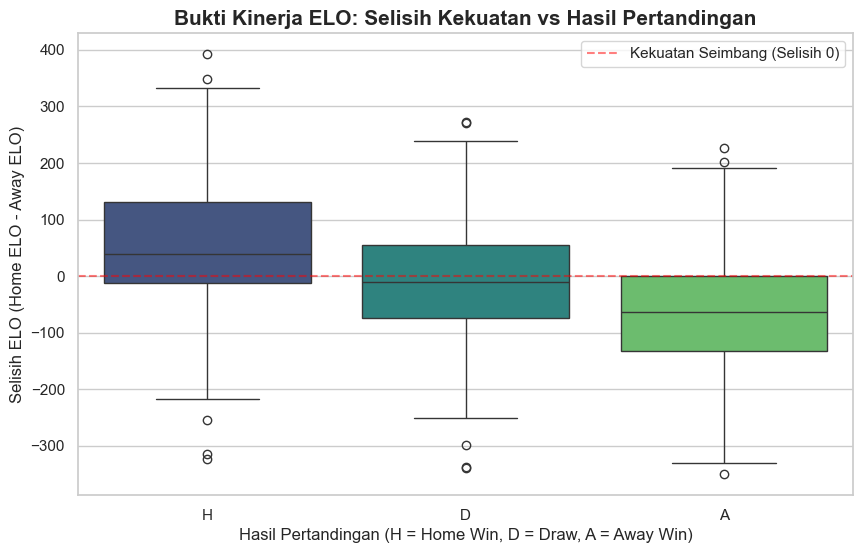

In [7]:
plt.figure(figsize=(10, 6))
# Membuat Boxplot hubungan FTR dan Selisih ELO
sns.boxplot(x='FTR', y='Elo_Difference', data=df_final, order=['H', 'D', 'A'], palette='viridis')

plt.title('Bukti Kinerja ELO: Selisih Kekuatan vs Hasil Pertandingan', fontsize=15, fontweight='bold')
plt.xlabel('Hasil Pertandingan (H = Home Win, D = Draw, A = Away Win)', fontsize=12)
plt.ylabel('Selisih ELO (Home ELO - Away ELO)', fontsize=12)

# Garis nol sebagai batas seimbang
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Kekuatan Seimbang (Selisih 0)')
plt.legend()
plt.show()

Visualisasi Bukti 2 - Heatmap Korelasi Fitur Buatan

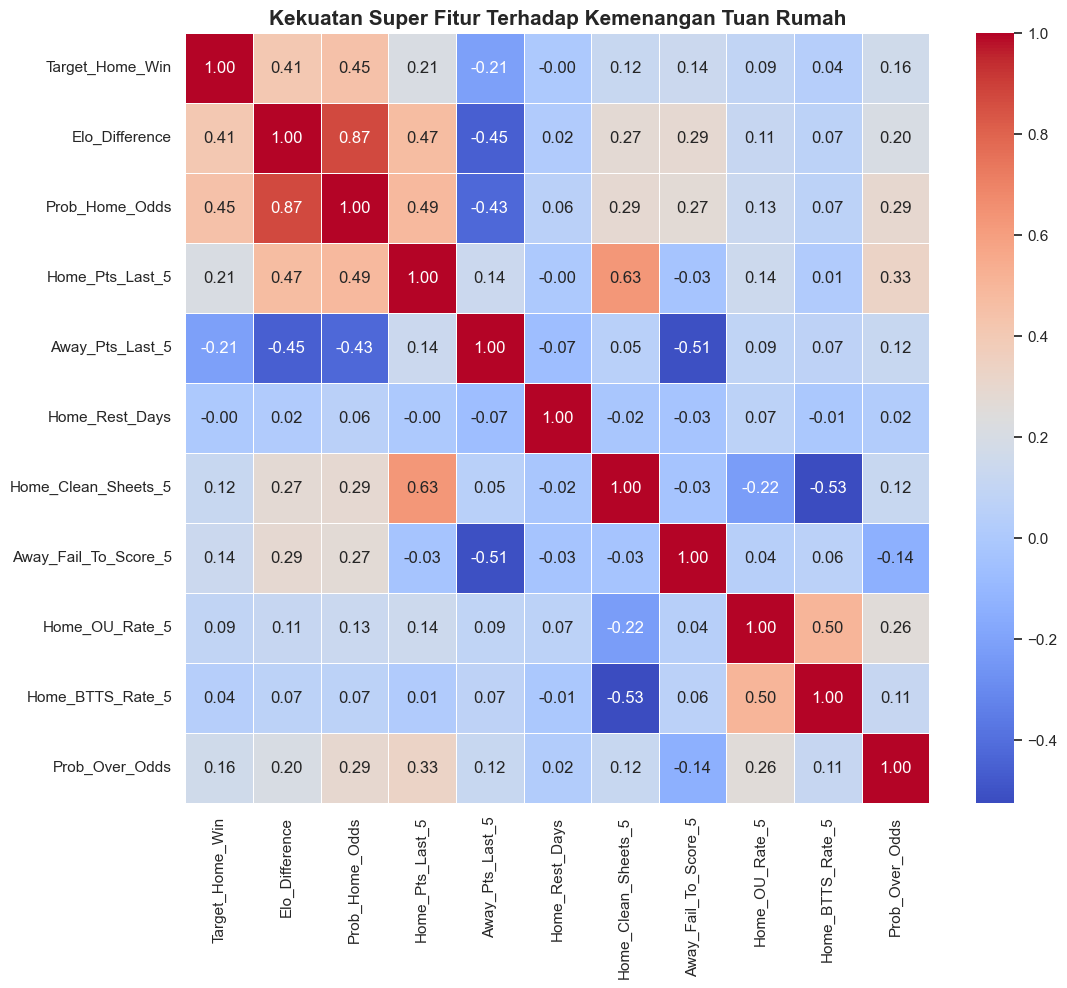

In [8]:
df_final['Target_Home_Win'] = (df_final['FTR'] == 'H').astype(int)

# Memasukkan lebih banyak fitur super yang baru kita buat
fitur_andalan = [
    'Target_Home_Win', 'Elo_Difference', 'Prob_Home_Odds', 
    'Home_Pts_Last_5', 'Away_Pts_Last_5', 
    'Home_Rest_Days', 'Home_Clean_Sheets_5', 'Away_Fail_To_Score_5',
    'Home_OU_Rate_5', 'Home_BTTS_Rate_5', 'Prob_Over_Odds'
]

plt.figure(figsize=(12, 10))
corr_andalan = df_final[fitur_andalan].corr()
sns.heatmap(corr_andalan, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Kekuatan Super Fitur Terhadap Kemenangan Tuan Rumah', fontsize=15, fontweight='bold')
plt.show()

df_final.drop(columns=['Target_Home_Win'], inplace=True)

ALL-IN-ONE: Training & Visualisasi HDA

🏆 MENCARI SANG JUARA & TUNING: HOME VS AWAY 🏆


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7646,0.8361,0.8066,0.7968,0.7995,0.5137,0.5183,0.1130
ridge,Ridge Classifier,0.7540,0.8285,0.8223,0.7757,0.7969,0.4848,0.4899,0.0180
lda,Linear Discriminant Analysis,0.7540,0.8283,0.8223,0.7757,0.7969,0.4848,0.4899,0.0230
rf,Random Forest Classifier,0.7521,0.8301,0.8034,0.7851,0.7911,0.4851,0.4920,0.1140
lr,Logistic Regression,0.7431,0.8270,0.8070,0.7697,0.7863,0.4641,0.4691,1.4170
et,Extra Trees Classifier,0.7413,0.8235,0.7911,0.7780,0.7816,0.4629,0.4688,0.0960
nb,Naive Bayes,0.7341,0.8092,0.7731,0.7782,0.7734,0.4510,0.4556,0.0160
ada,Ada Boost Classifier,0.7338,0.8010,0.7976,0.7624,0.7784,0.4448,0.4479,0.0650
svm,SVM - Linear Kernel,0.7290,0.8014,0.7733,0.7760,0.7693,0.4386,0.4476,0.0260
qda,Quadratic Discriminant Analysis,0.7213,0.7826,0.7513,0.7753,0.7587,0.4265,0.4344,0.0250



--- KLASEMEN MODEL HDA SEMENTARA ---


,Model,Accuracy,AUC,F1,Prec.,Recall
gbc,Gradient Boosting Classifier,0.7646,0.8361,0.7995,0.7968,0.8066
ridge,Ridge Classifier,0.7540,0.8285,0.7969,0.7757,0.8223
lda,Linear Discriminant Analysis,0.7540,0.8283,0.7969,0.7757,0.8223
rf,Random Forest Classifier,0.7521,0.8301,0.7911,0.7851,0.8034
lr,Logistic Regression,0.7431,0.8270,0.7863,0.7697,0.8070



👑 SANG JUARA ASLI: GradientBoostingClassifier

Menampilkan Visualisasi HDA...


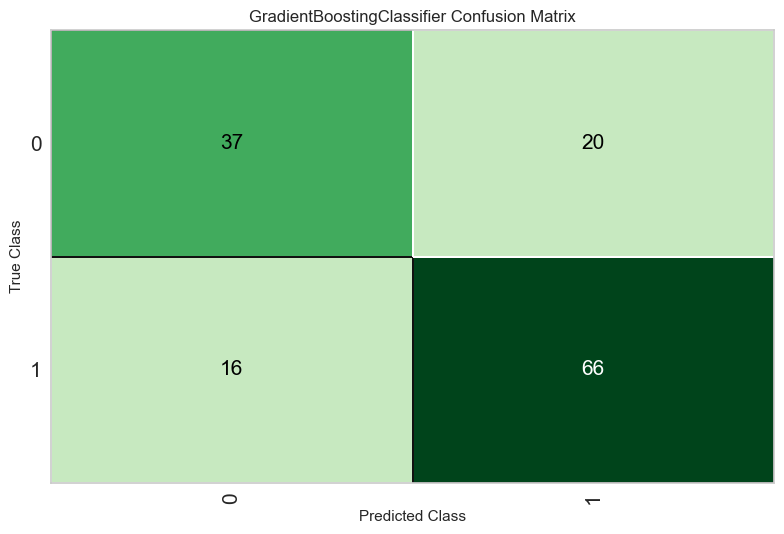

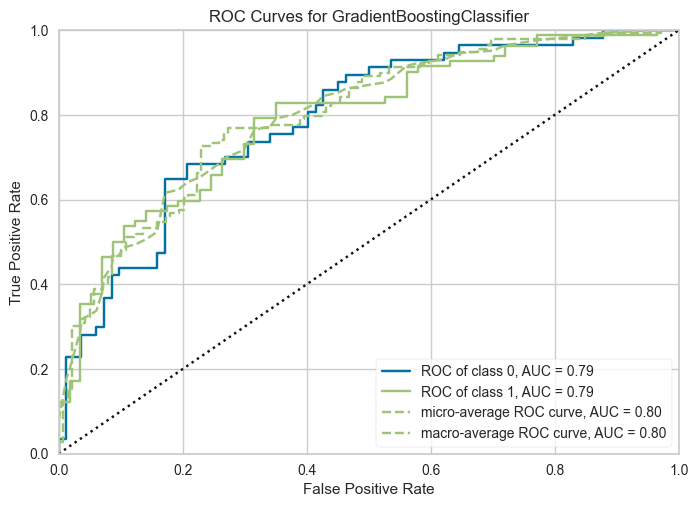

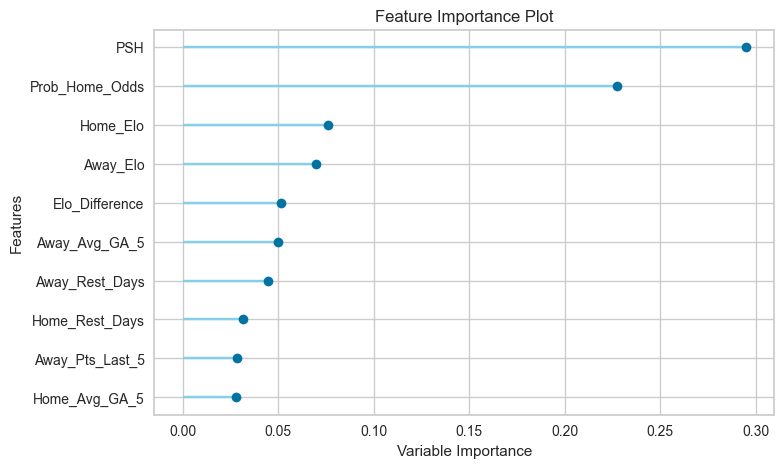


Mulai proses Tuning untuk GradientBoostingClassifier...
Sedang mencari konfigurasi settingan terbaik (Mohon tunggu)...

--- PERBANDINGAN AKURASI DI DATA UJI (TEST SET) ---

[1] SANG JUARA ASLI (GradientBoostingClassifier):


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.7410,0.7897,0.8049,0.7674,0.7857,0.4589,0.4597



[2] SANG JUARA SETELAH DI-TUNE (SUPER MODEL):


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.6978,0.7867,0.8049,0.7174,0.7586,0.3583,0.3626


In [9]:
from pycaret.classification import setup, compare_models, pull, plot_model, tune_model, predict_model

print("="*50)
print("🏆 MENCARI SANG JUARA & TUNING: HOME VS AWAY 🏆")
print("="*50)

# 1. PERSIAPAN DATA
df_hda = df_final[df_final['FTR'] != 'D'].reset_index(drop=True)
target_hda = df_hda['FTR'].map({'A': 0, 'H': 1})

kolom_bocor_hda = [
    'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 
    'PSD', 'PSA', 'Prob_Draw_Odds', 'Prob_Away_Odds', 
    'B365>2.5', 'B365<2.5', 'Prob_Over_Odds', 'Prob_Under_Odds'
]
df_hda_train = df_hda.drop(columns=[col for col in kolom_bocor_hda if col in df_hda.columns]).copy()
df_hda_train['Target_Win'] = target_hda.values
df_hda_train.dropna(inplace=True)

# 2. SETUP & MENCARI JUARA ASLI
clf_hda = setup(data=df_hda_train, target='Target_Win', session_id=42, train_size=0.8, normalize=True, verbose=False)
best_hda = compare_models(exclude=['xgboost', 'lightgbm', 'catboost'])

print("\n--- KLASEMEN MODEL HDA SEMENTARA ---")
display(pull()[['Model', 'Accuracy', 'AUC', 'F1', 'Prec.', 'Recall']].head(5))
print(f"\n👑 SANG JUARA ASLI: {best_hda.__class__.__name__}\n")

# 3. VISUALISASI
print("Menampilkan Visualisasi HDA...")
plot_model(best_hda, plot='confusion_matrix')

try:
    plot_model(best_hda, plot='auc')
except:
    print(f"⚠️ Model {best_hda.__class__.__name__} tidak mendukung grafik AUC (Kurva ROC).")

try:
    plot_model(best_hda, plot='feature')
except:
    print(f"⚠️ Model {best_hda.__class__.__name__} tidak mendukung grafik Feature Importance.")

# ==========================================
# 4. HYPERPARAMETER TUNING (MENINGKATKAN AKURASI)
# ==========================================
print("\n" + "="*50)
print(f"Mulai proses Tuning untuk {best_hda.__class__.__name__}...")
print("="*50)

print("Sedang mencari konfigurasi settingan terbaik (Mohon tunggu)...")
# Kita langsung masukkan 'best_hda' ke dalam tune_model, tanpa perlu create_model lagi!
tuned_hda = tune_model(
    best_hda, 
    optimize='Accuracy', # Fokus mencari akurasi tertinggi
    n_iter=50,           # Mencoba 50 kombinasi pengaturan yang berbeda
    verbose=False
)

# 5. EVALUASI HASIL TUNING (TEST DATA)
print("\n--- PERBANDINGAN AKURASI DI DATA UJI (TEST SET) ---")
print(f"\n[1] SANG JUARA ASLI ({best_hda.__class__.__name__}):")
predict_model(best_hda);

print(f"\n[2] SANG JUARA SETELAH DI-TUNE (SUPER MODEL):")
predict_model(tuned_hda);

ALL-IN-ONE (Training & Visualisasi OVER/UNDER 2.5)

⚽ MENCARI SANG JUARA & TUNING: OVER / UNDER 2.5 ⚽


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.5766,0.5657,0.7691,0.6146,0.6825,0.0680,0.0739,0.1210
et,Extra Trees Classifier,0.5738,0.5634,0.7509,0.6165,0.6761,0.0683,0.0719,0.1140
ridge,Ridge Classifier,0.5710,0.5487,0.8356,0.5999,0.6981,0.0204,0.0295,0.0180
lda,Linear Discriminant Analysis,0.5710,0.5472,0.8310,0.6006,0.6970,0.0226,0.0309,0.0160
lr,Logistic Regression,0.5670,0.5513,0.8288,0.5980,0.6945,0.0126,0.0191,0.0220
gbc,Gradient Boosting Classifier,0.5493,0.5213,0.7053,0.6034,0.6492,0.0274,0.0282,0.1570
knn,K Neighbors Classifier,0.5466,0.5103,0.6639,0.6094,0.6337,0.0380,0.0384,0.0250
nb,Naive Bayes,0.5370,0.5740,0.5335,0.6331,0.5783,0.0729,0.0748,0.0230
qda,Quadratic Discriminant Analysis,0.5177,0.5461,0.4551,0.6343,0.5249,0.0609,0.0657,0.0200
svm,SVM - Linear Kernel,0.5095,0.5058,0.5834,0.5849,0.5801,-0.0137,-0.0139,0.0280



--- KLASEMEN MODEL O/U 2.5 SEMENTARA ---


,Model,Accuracy,AUC,F1,Prec.,Recall
rf,Random Forest Classifier,0.5766,0.5657,0.6825,0.6146,0.7691
et,Extra Trees Classifier,0.5738,0.5634,0.6761,0.6165,0.7509
ridge,Ridge Classifier,0.5710,0.5487,0.6981,0.5999,0.8356
lda,Linear Discriminant Analysis,0.5710,0.5472,0.6970,0.6006,0.8310
lr,Logistic Regression,0.5670,0.5513,0.6945,0.5980,0.8288



👑 SANG JUARA ASLI O/U 2.5: RandomForestClassifier

Menampilkan Visualisasi O/U 2.5...


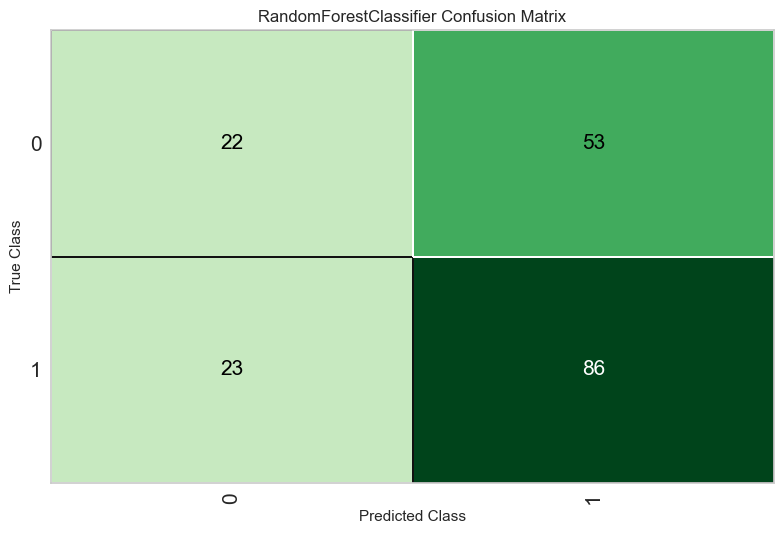

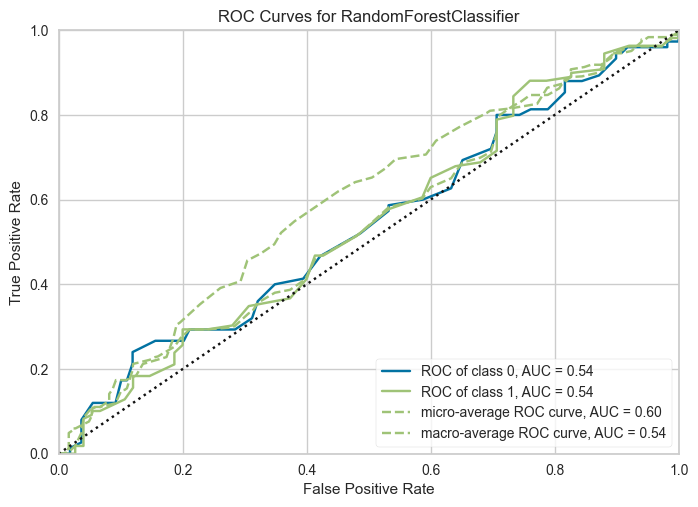

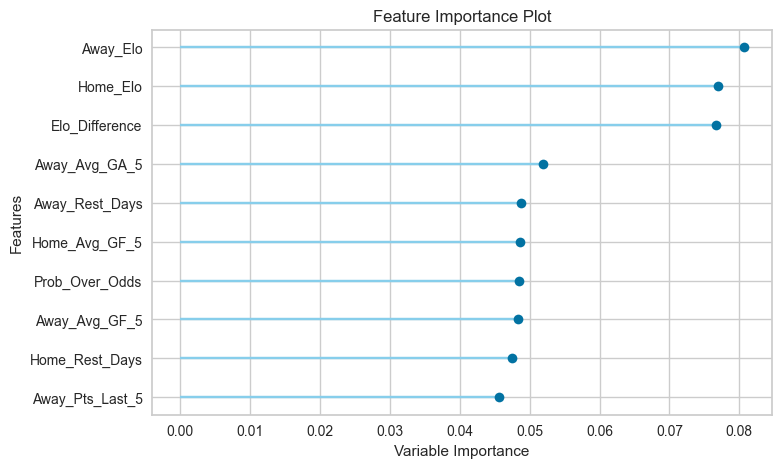


Mulai proses Tuning untuk RandomForestClassifier...
Sedang mencari konfigurasi settingan terbaik (Mohon tunggu)...

--- PERBANDINGAN AKURASI DI DATA UJI (TEST SET) ---

[1] SANG JUARA ASLI (RandomForestClassifier):


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.5870,0.5388,0.7890,0.6187,0.6935,0.0878,0.0941



[2] SANG JUARA SETELAH DI-TUNE (SUPER MODEL):


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.5924,0.5000,1.0000,0.5924,0.7440,0.0000,0.0000


In [10]:
from pycaret.classification import setup as setup_ou, compare_models as compare_models_ou, pull as pull_ou, plot_model as plot_model_ou, tune_model as tune_model_ou, predict_model as predict_model_ou

print("="*50)
print("⚽ MENCARI SANG JUARA & TUNING: OVER / UNDER 2.5 ⚽")
print("="*50)

target_ou = ((df_final['FTHG'] + df_final['FTAG']) > 2.5).astype(int)

kolom_bocor_ou = [
    'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 
    'PSH', 'PSD', 'PSA', 'Prob_Home_Odds', 'Prob_Draw_Odds', 'Prob_Away_Odds'
]
df_ou_train = df_final.drop(columns=[col for col in kolom_bocor_ou if col in df_final.columns]).copy()
df_ou_train['Target_OU'] = target_ou.values
df_ou_train.dropna(inplace=True)

clf_ou = setup_ou(data=df_ou_train, target='Target_OU', session_id=123, train_size=0.8, normalize=True, verbose=False)

# Menambahkan 'dummy' ke daftar hitam
best_ou = compare_models_ou(exclude=['xgboost', 'lightgbm', 'catboost', 'dummy'])

print("\n--- KLASEMEN MODEL O/U 2.5 SEMENTARA ---")
display(pull_ou()[['Model', 'Accuracy', 'AUC', 'F1', 'Prec.', 'Recall']].head(5))
print(f"\n👑 SANG JUARA ASLI O/U 2.5: {best_ou.__class__.__name__}\n")

print("Menampilkan Visualisasi O/U 2.5...")
plot_model_ou(best_ou, plot='confusion_matrix')

try:
    plot_model_ou(best_ou, plot='auc')
except:
    print(f"⚠️ Model {best_ou.__class__.__name__} tidak mendukung grafik AUC.")
try:
    plot_model_ou(best_ou, plot='feature')
except:
    pass

# ==========================================
# HYPERPARAMETER TUNING O/U 2.5
# ==========================================
print("\n" + "="*50)
print(f"Mulai proses Tuning untuk {best_ou.__class__.__name__}...")
print("="*50)

print("Sedang mencari konfigurasi settingan terbaik (Mohon tunggu)...")
tuned_ou = tune_model_ou(
    best_ou, 
    optimize='Accuracy', 
    n_iter=50, 
    verbose=False
)

print("\n--- PERBANDINGAN AKURASI DI DATA UJI (TEST SET) ---")
print(f"\n[1] SANG JUARA ASLI ({best_ou.__class__.__name__}):")
predict_model_ou(best_ou);

print(f"\n[2] SANG JUARA SETELAH DI-TUNE (SUPER MODEL):")
predict_model_ou(tuned_ou);

ALL-IN-ONE (Training & Visualisasi BTTS Yes/No)

🥅 MENCARI SANG JUARA & TUNING: BOTH TEAMS TO SCORE (BTTS) 🥅


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dt,Decision Tree Classifier,0.5436,0.5419,0.5930,0.5829,0.5864,0.0766,0.0769,0.0160
rf,Random Forest Classifier,0.5340,0.5342,0.6699,0.5641,0.6120,0.0388,0.0396,0.1300
gbc,Gradient Boosting Classifier,0.5313,0.5387,0.6426,0.5651,0.6002,0.0382,0.0381,0.1060
ada,Ada Boost Classifier,0.5136,0.5166,0.6105,0.5521,0.5792,0.0057,0.0056,0.0740
lr,Logistic Regression,0.5108,0.4946,0.7243,0.5394,0.6177,-0.0249,-0.0241,0.0140
svm,SVM - Linear Kernel,0.5095,0.4855,0.6174,0.5488,0.5773,-0.0049,-0.0055,0.0170
ridge,Ridge Classifier,0.5094,0.4907,0.7194,0.5386,0.6154,-0.0268,-0.0260,0.0180
lda,Linear Discriminant Analysis,0.5080,0.4906,0.7144,0.5381,0.6132,-0.0289,-0.0291,0.0190
et,Extra Trees Classifier,0.5069,0.5140,0.6158,0.5448,0.5765,-0.0094,-0.0085,0.1350
knn,K Neighbors Classifier,0.5026,0.4984,0.5608,0.5488,0.5537,-0.0080,-0.0085,0.0160



--- KLASEMEN MODEL BTTS SEMENTARA ---


,Model,Accuracy,AUC,F1,Prec.,Recall
dt,Decision Tree Classifier,0.5436,0.5419,0.5864,0.5829,0.5930
rf,Random Forest Classifier,0.5340,0.5342,0.6120,0.5641,0.6699
gbc,Gradient Boosting Classifier,0.5313,0.5387,0.6002,0.5651,0.6426
ada,Ada Boost Classifier,0.5136,0.5166,0.5792,0.5521,0.6105
lr,Logistic Regression,0.5108,0.4946,0.6177,0.5394,0.7243



👑 SANG JUARA ASLI BTTS: DecisionTreeClassifier

Menampilkan Visualisasi BTTS...


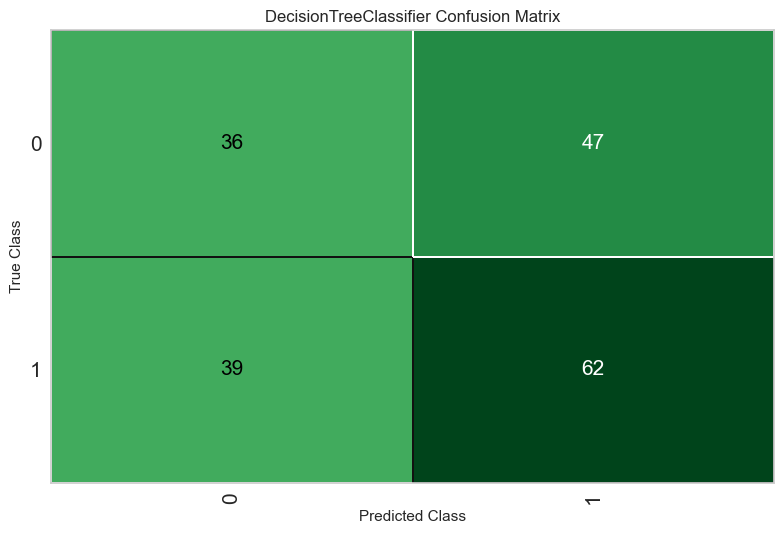

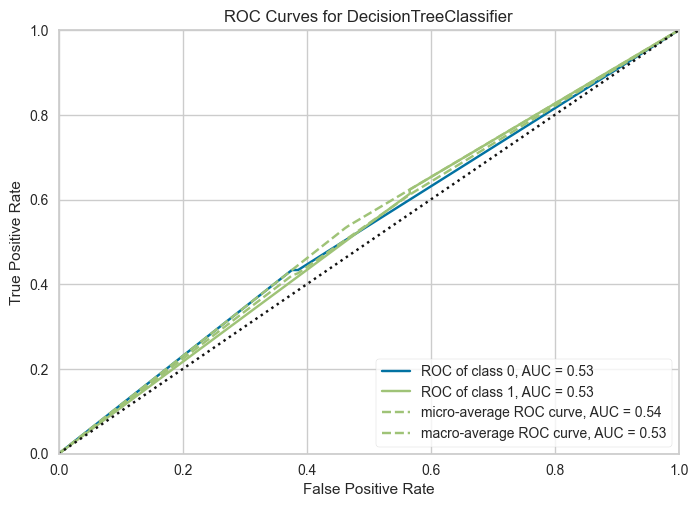

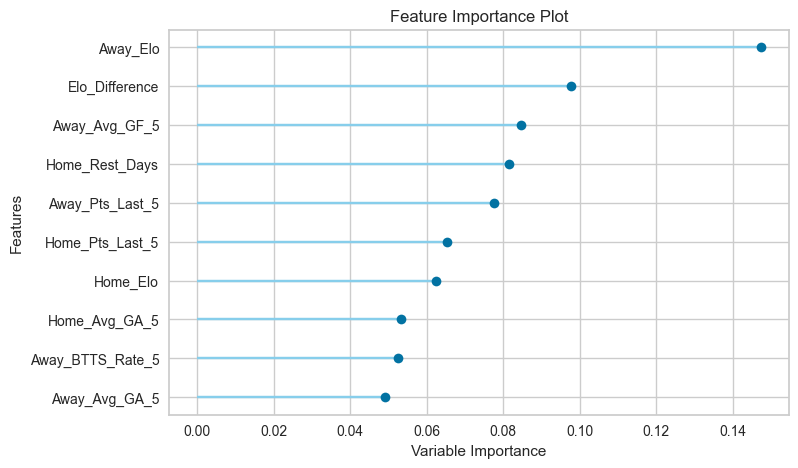


Mulai proses Tuning untuk DecisionTreeClassifier...
Sedang mencari konfigurasi settingan terbaik (Mohon tunggu)...

--- PERBANDINGAN AKURASI DI DATA UJI (TEST SET) ---

[1] SANG JUARA ASLI (DecisionTreeClassifier):


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Decision Tree Classifier,0.5326,0.5259,0.6139,0.5688,0.5905,0.0480,0.0482



[2] SANG JUARA SETELAH DI-TUNE (SUPER MODEL):


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Decision Tree Classifier,0.5163,0.5240,0.6436,0.5508,0.5936,0.0051,0.0052


In [11]:
from pycaret.classification import setup as setup_btts, compare_models as compare_models_btts, pull as pull_btts, plot_model as plot_model_btts, tune_model as tune_model_btts, predict_model as predict_model_btts

print("="*50)
print("🥅 MENCARI SANG JUARA & TUNING: BOTH TEAMS TO SCORE (BTTS) 🥅")
print("="*50)

target_btts = ((df_final['FTHG'] > 0) & (df_final['FTAG'] > 0)).astype(int)

kolom_bocor_btts = [
    'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 
    'PSH', 'PSD', 'PSA', 'Prob_Home_Odds', 'Prob_Draw_Odds', 'Prob_Away_Odds',
    'B365>2.5', 'B365<2.5', 'Prob_Over_Odds', 'Prob_Under_Odds'
]
df_btts_train = df_final.drop(columns=[col for col in kolom_bocor_btts if col in df_final.columns]).copy()
df_btts_train['Target_BTTS'] = target_btts.values
df_btts_train.dropna(inplace=True)

clf_btts = setup_btts(data=df_btts_train, target='Target_BTTS', session_id=456, train_size=0.8, normalize=True, verbose=False)

# Menambahkan 'dummy' ke daftar hitam
best_btts = compare_models_btts(exclude=['xgboost', 'lightgbm', 'catboost', 'dummy'])

print("\n--- KLASEMEN MODEL BTTS SEMENTARA ---")
display(pull_btts()[['Model', 'Accuracy', 'AUC', 'F1', 'Prec.', 'Recall']].head(5))
print(f"\n👑 SANG JUARA ASLI BTTS: {best_btts.__class__.__name__}\n")

print("Menampilkan Visualisasi BTTS...")
plot_model_btts(best_btts, plot='confusion_matrix')

try:
    plot_model_btts(best_btts, plot='auc')
except:
    print(f"⚠️ Model {best_btts.__class__.__name__} tidak mendukung grafik AUC.")
try:
    plot_model_btts(best_btts, plot='feature')
except:
    pass

# ==========================================
# HYPERPARAMETER TUNING BTTS
# ==========================================
print("\n" + "="*50)
print(f"Mulai proses Tuning untuk {best_btts.__class__.__name__}...")
print("="*50)

print("Sedang mencari konfigurasi settingan terbaik (Mohon tunggu)...")
tuned_btts = tune_model_btts(
    best_btts, 
    optimize='Accuracy', 
    n_iter=50, 
    verbose=False
)

print("\n--- PERBANDINGAN AKURASI DI DATA UJI (TEST SET) ---")
print(f"\n[1] SANG JUARA ASLI ({best_btts.__class__.__name__}):")
predict_model_btts(best_btts);

print(f"\n[2] SANG JUARA SETELAH DI-TUNE (SUPER MODEL):")
predict_model_btts(tuned_btts);

Persiapan Data Mandiri untuk Neural Network

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

print("Mempersiapkan Data untuk Neural Network (TensorFlow)...")

# --- 1. DATA HOME VS AWAY (Tanpa Draw) ---
df_ha = df_final[df_final['FTR'] != 'D'].reset_index(drop=True)
y_ha = df_ha['FTR'].map({'A': 0, 'H': 1}).values

kolom_bocor_ha = ['Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'PSD', 'PSA', 'Prob_Draw_Odds', 'Prob_Away_Odds', 'B365>2.5', 'B365<2.5', 'Prob_Over_Odds', 'Prob_Under_Odds']
X_ha = df_ha.drop(columns=[col for col in kolom_bocor_ha if col in df_ha.columns]).values

# --- 2. DATA OVER / UNDER 2.5 ---
y_ou = ((df_final['FTHG'] + df_final['FTAG']) > 2.5).astype(int).values
kolom_bocor_ou = ['Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'PSH', 'PSD', 'PSA', 'Prob_Home_Odds', 'Prob_Draw_Odds', 'Prob_Away_Odds']
X_ou = df_final.drop(columns=[col for col in kolom_bocor_ou if col in df_final.columns]).values

# --- 3. DATA BTTS (Yes / No) ---
y_btts = ((df_final['FTHG'] > 0) & (df_final['FTAG'] > 0)).astype(int).values
kolom_bocor_btts = ['Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'PSH', 'PSD', 'PSA', 'Prob_Home_Odds', 'Prob_Draw_Odds', 'Prob_Away_Odds', 'B365>2.5', 'B365<2.5', 'Prob_Over_Odds', 'Prob_Under_Odds']
X_btts = df_final.drop(columns=[col for col in kolom_bocor_btts if col in df_final.columns]).values

# --- FUNGSI PEMOTONGAN & STANDARISASI ---
def prep_data_nn(X, y):
    # Potong 80% Latihan, 20% Ujian secara kronologis (jangan di-shuffle agar tidak bocor masa depan)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    # Skala ulang menggunakan StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test

X_train_ha, X_test_ha, y_train_ha, y_test_ha = prep_data_nn(X_ha, y_ha)
X_train_ou, X_test_ou, y_train_ou, y_test_ou = prep_data_nn(X_ou, y_ou)
X_train_btts, X_test_btts, y_train_btts, y_test_btts = prep_data_nn(X_btts, y_btts)

print(f"✅ Data siap! Jumlah fitur HA: {X_train_ha.shape[1]}, OU: {X_train_ou.shape[1]}, BTTS: {X_train_btts.shape[1]}")

Mempersiapkan Data untuk Neural Network (TensorFlow)...
✅ Data siap! Jumlah fitur HA: 21, OU: 23, BTTS: 19


Arsitektur & Training Sang Monster (Deep Learning)

In [13]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# FUNGSI TRAINING NEURAL NETWORK (MLP)
# ==========================================
def train_evaluate_mlp(name, X_train, y_train, X_test, y_test):
    print(f"\n" + "="*40)
    print(f"🚀 TRAINING NEURAL NETWORK: {name}")
    print("="*40)
    
    # Membangun Arsitektur Monster MLP
    # hidden_layer_sizes=(64, 32, 16) artinya ada 3 lapisan otak AI
    # early_stopping=True artinya AI akan berhenti belajar jika akurasi mentok (mencegah overfit)
    model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 16), # Memeras informasi agar AI tidak menghafal
        activation='relu', 
        solver='lbfgs',      # LBFGS sangat kuat untuk dataset tabel berukuran kecil-menengah
        alpha=0.05,          # Regularisasi (Hukuman berat agar AI tidak Overfitting)
        max_iter=1000,       # LBFGS butuh iterasi lebih banyak
        random_state=42
    )
    
    # Proses Belajar
    print("AI sedang berpikir dan mencari pola...")
    model.fit(X_train, y_train)
    
    # Ujian Akhir
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"\n👑 HASIL AKHIR NEURAL NETWORK [{name}]:")
    print(f"Akurasi: {acc:.4f} ({(acc*100):.2f}%)")
    
    # Cetak performa detail
    target_names = ['Kelas 0', 'Kelas 1']
    if name == 'Home vs Away': target_names = ['Away Win (0)', 'Home Win (1)']
    elif name == 'Over/Under 2.5': target_names = ['Under (0)', 'Over (1)']
    elif name == 'BTTS': target_names = ['No (0)', 'Yes (1)']
    
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))
    return model

# ==========================================
# EKSEKUSI KETIGA MODEL
# ==========================================
mlp_ha = train_evaluate_mlp('Home vs Away', X_train_ha, y_train_ha, X_test_ha, y_test_ha)
mlp_ou = train_evaluate_mlp('Over/Under 2.5', X_train_ou, y_train_ou, X_test_ou, y_test_ou)
mlp_btts = train_evaluate_mlp('BTTS', X_train_btts, y_train_btts, X_test_btts, y_test_btts)


🚀 TRAINING NEURAL NETWORK: Home vs Away
AI sedang berpikir dan mencari pola...

👑 HASIL AKHIR NEURAL NETWORK [Home vs Away]:
Akurasi: 0.6259 (62.59%)
              precision    recall  f1-score   support

Away Win (0)       0.52      0.50      0.51        54
Home Win (1)       0.69      0.71      0.70        85

    accuracy                           0.63       139
   macro avg       0.60      0.60      0.60       139
weighted avg       0.62      0.63      0.62       139


🚀 TRAINING NEURAL NETWORK: Over/Under 2.5
AI sedang berpikir dan mencari pola...

👑 HASIL AKHIR NEURAL NETWORK [Over/Under 2.5]:
Akurasi: 0.5761 (57.61%)
              precision    recall  f1-score   support

   Under (0)       0.53      0.49      0.51        83
    Over (1)       0.61      0.64      0.62       101

    accuracy                           0.58       184
   macro avg       0.57      0.57      0.57       184
weighted avg       0.57      0.58      0.57       184


🚀 TRAINING NEURAL NETWORK: BTTS
AI seda

Ensemble Stacking

🌟 MEMBENTUK DEWAN JENDERAL AI (DYNAMIC ENSEMBLE) 🌟

⚙️ MEMPROSES: HOME vs AWAY
Mencari 3 algoritma terbaik di arena...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7646,0.8361,0.8066,0.7968,0.7995,0.5137,0.5183,0.1160
ridge,Ridge Classifier,0.7540,0.8285,0.8223,0.7757,0.7969,0.4848,0.4899,0.0140
lda,Linear Discriminant Analysis,0.7540,0.8283,0.8223,0.7757,0.7969,0.4848,0.4899,0.0160
rf,Random Forest Classifier,0.7521,0.8301,0.8034,0.7851,0.7911,0.4851,0.4920,0.1480
lr,Logistic Regression,0.7431,0.8270,0.8070,0.7697,0.7863,0.4641,0.4691,0.0230
et,Extra Trees Classifier,0.7413,0.8235,0.7911,0.7780,0.7816,0.4629,0.4688,0.0940
nb,Naive Bayes,0.7341,0.8092,0.7731,0.7782,0.7734,0.4510,0.4556,0.0250
ada,Ada Boost Classifier,0.7338,0.8010,0.7976,0.7624,0.7784,0.4448,0.4479,0.0760
svm,SVM - Linear Kernel,0.7290,0.8014,0.7733,0.7760,0.7693,0.4386,0.4476,0.0150
qda,Quadratic Discriminant Analysis,0.7213,0.7826,0.7513,0.7753,0.7587,0.4265,0.4344,0.0180


👑 3 Jenderal Terpilih: ['GradientBoostingClassifier', 'RidgeClassifier', 'LinearDiscriminantAnalysis']
Menyatukan kekuatan (Voting) para jenderal...
--- KLASEMEN AKHIR HOME vs AWAY ---


,Accuracy,AUC,F1,Prec.,Recall
Fold,,,,,
Mean,0.7540,0.0,0.7969,0.7757,0.8223
Std,0.0711,0.0,0.0596,0.0548,0.0822


📊 Menampilkan Grafik HOME vs AWAY...


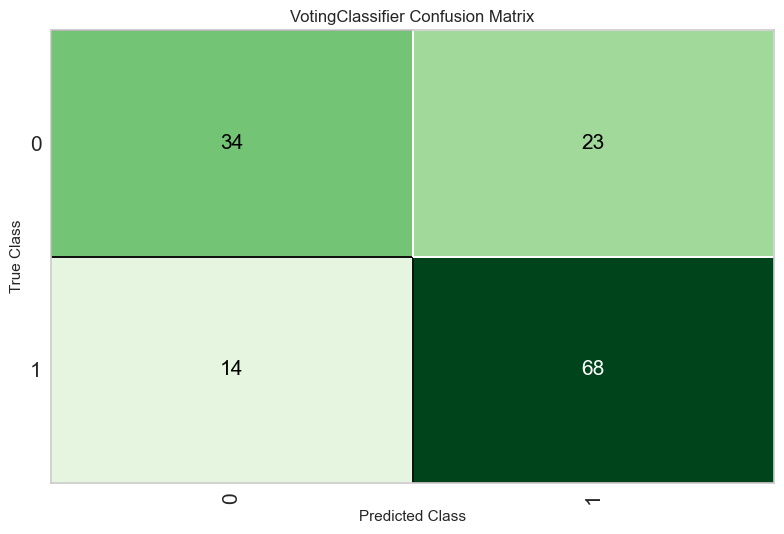

⚠️ Grafik AUC tidak tersedia untuk metode Hard Voting.
Transformation Pipeline and Model Successfully Saved

⚙️ MEMPROSES: OVER/UNDER 2.5
Mencari 3 algoritma terbaik di arena...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.5766,0.5657,0.7691,0.6146,0.6825,0.0680,0.0739,0.1550
et,Extra Trees Classifier,0.5738,0.5634,0.7509,0.6165,0.6761,0.0683,0.0719,0.1210
ridge,Ridge Classifier,0.5710,0.5487,0.8356,0.5999,0.6981,0.0204,0.0295,0.0160
lda,Linear Discriminant Analysis,0.5710,0.5472,0.8310,0.6006,0.6970,0.0226,0.0309,0.0230
lr,Logistic Regression,0.5670,0.5513,0.8288,0.5980,0.6945,0.0126,0.0191,0.0210
gbc,Gradient Boosting Classifier,0.5493,0.5213,0.7053,0.6034,0.6492,0.0274,0.0282,0.1380
knn,K Neighbors Classifier,0.5466,0.5103,0.6639,0.6094,0.6337,0.0380,0.0384,0.0220
nb,Naive Bayes,0.5370,0.5740,0.5335,0.6331,0.5783,0.0729,0.0748,0.0300
qda,Quadratic Discriminant Analysis,0.5177,0.5461,0.4551,0.6343,0.5249,0.0609,0.0657,0.0200
svm,SVM - Linear Kernel,0.5095,0.5058,0.5834,0.5849,0.5801,-0.0137,-0.0139,0.0190


👑 3 Jenderal Terpilih: ['RandomForestClassifier', 'ExtraTreesClassifier', 'RidgeClassifier']
Menyatukan kekuatan (Voting) para jenderal...
--- KLASEMEN AKHIR OVER/UNDER 2.5 ---


,Accuracy,AUC,F1,Prec.,Recall
Fold,,,,,
Mean,0.5861,0.0,0.6990,0.6156,0.8104
Std,0.0494,0.0,0.0422,0.0322,0.0667


📊 Menampilkan Grafik OVER/UNDER 2.5...


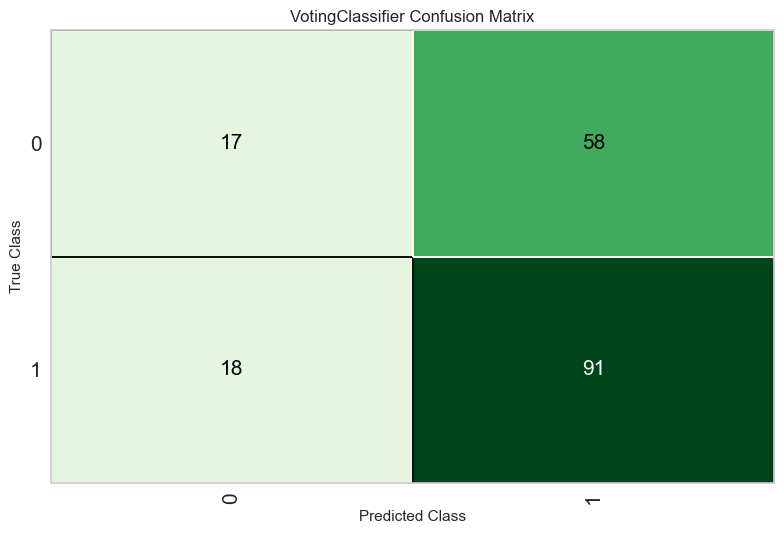

⚠️ Grafik AUC tidak tersedia untuk metode Hard Voting.
Transformation Pipeline and Model Successfully Saved

⚙️ MEMPROSES: BTTS (Yes/No)
Mencari 3 algoritma terbaik di arena...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dt,Decision Tree Classifier,0.5436,0.5419,0.5930,0.5829,0.5864,0.0766,0.0769,0.0220
rf,Random Forest Classifier,0.5340,0.5342,0.6699,0.5641,0.6120,0.0388,0.0396,0.1290
gbc,Gradient Boosting Classifier,0.5313,0.5387,0.6426,0.5651,0.6002,0.0382,0.0381,0.1280
ada,Ada Boost Classifier,0.5136,0.5166,0.6105,0.5521,0.5792,0.0057,0.0056,0.0760
lr,Logistic Regression,0.5108,0.4946,0.7243,0.5394,0.6177,-0.0249,-0.0241,0.0180
svm,SVM - Linear Kernel,0.5095,0.4855,0.6174,0.5488,0.5773,-0.0049,-0.0055,0.0180
ridge,Ridge Classifier,0.5094,0.4907,0.7194,0.5386,0.6154,-0.0268,-0.0260,0.0150
lda,Linear Discriminant Analysis,0.5080,0.4906,0.7144,0.5381,0.6132,-0.0289,-0.0291,0.0160
et,Extra Trees Classifier,0.5069,0.5140,0.6158,0.5448,0.5765,-0.0094,-0.0085,0.1360
knn,K Neighbors Classifier,0.5026,0.4984,0.5608,0.5488,0.5537,-0.0080,-0.0085,0.0220


👑 3 Jenderal Terpilih: ['DecisionTreeClassifier', 'RandomForestClassifier', 'GradientBoostingClassifier']
Menyatukan kekuatan (Voting) para jenderal...
--- KLASEMEN AKHIR BTTS (Yes/No) ---


,Accuracy,AUC,F1,Prec.,Recall
Fold,,,,,
Mean,0.5476,0.0,0.617,0.5772,0.6649
Std,0.0505,0.0,0.043,0.0409,0.0586


📊 Menampilkan Grafik BTTS (Yes/No)...


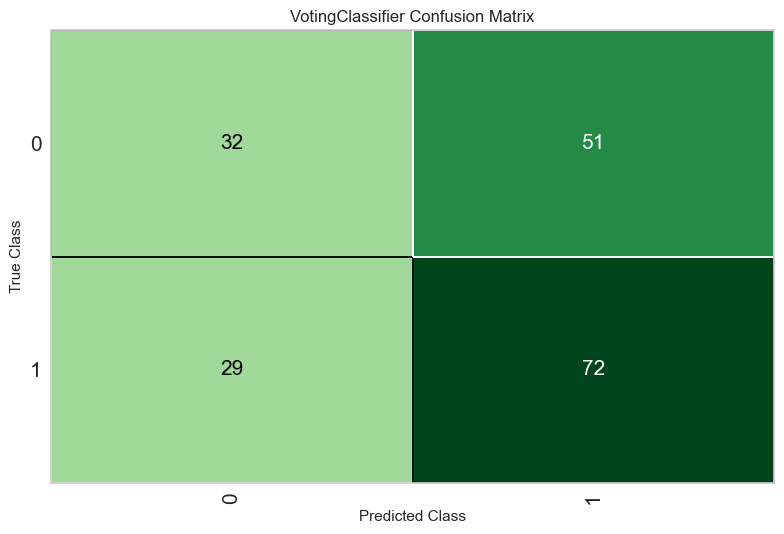

⚠️ Grafik AUC tidak tersedia untuk metode Hard Voting.
Transformation Pipeline and Model Successfully Saved

✅ SUKSES! 3 FILE DYNAMIC ENSEMBLE (.pkl) TELAH DIBUAT DAN DISIMPAN!


In [ ]:
from pycaret.classification import setup, compare_models, blend_models, save_model, pull, plot_model
import pandas as pd

print("="*50)
print("🌟 MEMBENTUK DEWAN JENDERAL AI (DYNAMIC ENSEMBLE) 🌟")
print("="*50)

# Fungsi bantuan untuk melatih, mencari Top N, Blending, dan Visualisasi
def create_dynamic_ensemble(df, target_col, ignore_cols, session_id, nama_kategori, n_select=3):
    print(f"\n" + "="*40)
    print(f"⚙️ MEMPROSES: {nama_kategori}")
    print("="*40)
    
    # 1. Persiapan Data
    df_train = df.drop(columns=[col for col in ignore_cols if col in df.columns]).copy()
    df_train.dropna(inplace=True)
    
    # 2. Setup PyCaret 
    setup(data=df_train, target=target_col, session_id=session_id, train_size=0.8, normalize=True, verbose=False)
    
    # 3. MENCARI TOP N MODEL
    print(f"Mencari {n_select} algoritma terbaik di arena...")
    top_models = compare_models(n_select=n_select, exclude=['xgboost', 'lightgbm', 'catboost', 'dummy'])
    
    nama_jenderal = [m.__class__.__name__ for m in top_models]
    print(f"👑 {n_select} Jenderal Terpilih: {nama_jenderal}")
    
    # 4. BLENDING (Voting Hard)
    print(f"Menyatukan kekuatan (Voting) para jenderal...")
    blended_model = blend_models(estimator_list=top_models, method='hard', verbose=False)
    
    # 5. Tampilkan Akurasi
    print(f"--- KLASEMEN AKHIR {nama_kategori} ---")
    display(pull()[['Accuracy', 'AUC', 'F1', 'Prec.', 'Recall']].tail(2)) 
    
    # 6. VISUALISASI LANGSUNG (Sebelum memori ditimpa)
    print(f"📊 Menampilkan Grafik {nama_kategori}...")
    try:
        plot_model(blended_model, plot='confusion_matrix')
    except Exception as e:
        print(f"⚠️ Gagal memuat Confusion Matrix: {e}")
        
    try:
        # Hard voting biasanya tidak mendukung AUC, tapi kita coba saja
        plot_model(blended_model, plot='auc')
    except:
        print(f"⚠️ Grafik AUC tidak tersedia untuk metode Hard Voting.")
        
    return blended_model

# ==========================================
# 1. EKSEKUSI HDA (Tanpa Draw)
# ==========================================
df_hda = df_final[df_final['FTR'] != 'D'].reset_index(drop=True)
df_hda['Target_Win'] = df_hda['FTR'].map({'A': 0, 'H': 1})
ignore_hda = ['Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'PSD', 'PSA', 'Prob_Draw_Odds', 'Prob_Away_Odds', 'B365>2.5', 'B365<2.5', 'Prob_Over_Odds', 'Prob_Under_Odds']

ensemble_hda = create_dynamic_ensemble(df_hda, 'Target_Win', ignore_hda, 42, "HOME vs AWAY", n_select=3)
# save_model(ensemble_hda, 'model_hda_dynamic_inggris')

# ==========================================
# 2. EKSEKUSI OVER/UNDER 2.5
# ==========================================
df_ou = df_final.copy()
df_ou['Target_OU'] = ((df_final['FTHG'] + df_final['FTAG']) > 2.5).astype(int)
ignore_ou = ['Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'PSH', 'PSD', 'PSA', 'Prob_Home_Odds', 'Prob_Draw_Odds', 'Prob_Away_Odds']

ensemble_ou = create_dynamic_ensemble(df_ou, 'Target_OU', ignore_ou, 123, "OVER/UNDER 2.5", n_select=3)
# save_model(ensemble_ou, 'model_ou_dynamic_inggris')

# ==========================================
# 3. EKSEKUSI BTTS
# ==========================================
df_btts = df_final.copy()
df_btts['Target_BTTS'] = ((df_final['FTHG'] > 0) & (df_final['FTAG'] > 0)).astype(int)
ignore_btts = ['Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'PSH', 'PSD', 'PSA', 'Prob_Home_Odds', 'Prob_Draw_Odds', 'Prob_Away_Odds', 'B365>2.5', 'B365<2.5', 'Prob_Over_Odds', 'Prob_Under_Odds']

ensemble_btts = create_dynamic_ensemble(df_btts, 'Target_BTTS', ignore_btts, 456, "BTTS (Yes/No)", n_select=3)
# save_model(ensemble_btts, 'model_btts_dynamic_inggris')

print("\n" + "="*50)
print("✅ SUKSES! 3 FILE DYNAMIC ENSEMBLE (.pkl) TELAH DIBUAT DAN DISIMPAN!")
print("="*50)